In [176]:
import numpy as np 
import pandas as pd
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt

In [178]:
df = pd.read_csv('synthetic_glucose_dataset_2.csv')

In [180]:
df.head()

,Age,Sex,Ethnicity,BMI,Socioeconomic_Status,Physical_Activity,Alcohol_Consumption,Smoking_Status,Sleep_Duration,Sleep_Quality,...,Cardiovascular_Disease,Kidney_Problems,Medications,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Heart_Rate,Skin_Temperature,Blood_Glucose,Sensor_Current_uA,Sensor_Voltage_mV
0,47,Male,South Asian,18.6,Middle,Sedentary,NaN,Never,5.3,Average,...,No,No,Metformin,114,84,78,32.0,79.6,0.89,184.7
1,38,Male,South Asian,18.4,Middle,Sedentary,Moderate,Current,5.9,Average,...,No,No,NaN,103,72,72,31.4,99.9,0.95,183.9
2,50,Male,Hispanic,18.0,Middle,Sedentary,NaN,Never,7.0,Average,...,No,No,NaN,117,86,81,33.6,140.5,1.36,268.9
3,63,Male,Caucasian,29.1,Low,Active,Heavy,Current,5.8,Average,...,No,No,Metformin,110,69,79,32.2,98.2,0.98,202.9
4,36,Male,South Asian,29.1,Low,Active,NaN,Never,4.0,Average,...,No,No,NaN,128,86,75,30.9,104.5,1.06,216.0


In [182]:
df.describe()

,Age,BMI,Sleep_Duration,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Heart_Rate,Skin_Temperature,Blood_Glucose,Sensor_Current_uA,Sensor_Voltage_mV
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000
mean,40.533000,25.320440,6.952040,120.045400,80.118000,75.131600,32.00926,107.989940,1.078330,215.687060
std,13.945315,4.697433,1.435978,14.638736,9.989877,10.084177,0.97270,28.929394,0.289562,58.125509
min,18.000000,18.000000,4.000000,90.000000,60.000000,50.000000,30.00000,68.500000,0.540000,106.300000
25%,30.000000,21.700000,5.900000,110.000000,73.000000,69.000000,31.30000,86.600000,0.870000,173.900000
50%,40.000000,25.200000,7.000000,120.000000,80.000000,75.000000,32.00000,100.700000,1.030000,205.200000
75%,50.000000,28.600000,8.000000,130.000000,87.000000,82.000000,32.70000,120.900000,1.210000,241.400000
max,80.000000,40.000000,10.000000,176.000000,116.000000,109.000000,35.00000,235.500000,2.000000,412.500000


### 2. Glucose Distribution 
    Min: 68.5 and Max: 235.5

    This tells us your dataset covers:

    🔵 Healthy (70–99 mg/dL)

    🟡 Prediabetic (100–125 mg/dL)

    🔴 Diabetic (126–300 mg/dL upper clipped)

    Std = ~29 → Good spread, so that model can learn variations well.

    3. Sensor Values are Proportional
    Current and voltage scale linearly and match physical sensor behavior.

    Voltage = Current × 200 + noise is respected, and capped safely.


In [185]:
df.isna().sum()

Age                            0
Sex                            0
Ethnicity                      0
BMI                            0
Socioeconomic_Status           0
Physical_Activity              0
Alcohol_Consumption         3008
Smoking_Status                 0
Sleep_Duration                 0
Sleep_Quality                  0
Stress_Levels                  0
Family_History_Diabetes        0
Prediabetes                    0
Gestational_Diabetes           0
Hypertension                   0
PCOS                           0
Cardiovascular_Disease         0
Kidney_Problems                0
Medications                 2993
Blood_Pressure_Systolic        0
Blood_Pressure_Diastolic       0
Heart_Rate                     0
Skin_Temperature               0
Blood_Glucose                  0
Sensor_Current_uA              0
Sensor_Voltage_mV              0
dtype: int64

In [187]:
df.fillna( value = "none", inplace=True)

In [189]:
df.isna().sum()

Age                         0
Sex                         0
Ethnicity                   0
BMI                         0
Socioeconomic_Status        0
Physical_Activity           0
Alcohol_Consumption         0
Smoking_Status              0
Sleep_Duration              0
Sleep_Quality               0
Stress_Levels               0
Family_History_Diabetes     0
Prediabetes                 0
Gestational_Diabetes        0
Hypertension                0
PCOS                        0
Cardiovascular_Disease      0
Kidney_Problems             0
Medications                 0
Blood_Pressure_Systolic     0
Blood_Pressure_Diastolic    0
Heart_Rate                  0
Skin_Temperature            0
Blood_Glucose               0
Sensor_Current_uA           0
Sensor_Voltage_mV           0
dtype: int64

In [191]:
df.dtypes

Age                           int64
Sex                          object
Ethnicity                    object
BMI                         float64
Socioeconomic_Status         object
Physical_Activity            object
Alcohol_Consumption          object
Smoking_Status               object
Sleep_Duration              float64
Sleep_Quality                object
Stress_Levels                object
Family_History_Diabetes      object
Prediabetes                  object
Gestational_Diabetes         object
Hypertension                 object
PCOS                         object
Cardiovascular_Disease       object
Kidney_Problems              object
Medications                  object
Blood_Pressure_Systolic       int64
Blood_Pressure_Diastolic      int64
Heart_Rate                    int64
Skin_Temperature            float64
Blood_Glucose               float64
Sensor_Current_uA           float64
Sensor_Voltage_mV           float64
dtype: object

In [193]:
df.columns = df.columns.str.lower()

In [195]:
df.select_dtypes(include = np.number).corr()

,age,bmi,sleep_duration,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,skin_temperature,blood_glucose,sensor_current_ua,sensor_voltage_mv
age,1.000000,-0.008386,0.017615,0.022011,-0.001349,-0.017260,0.009298,-0.029344,-0.027989,-0.027686
bmi,-0.008386,1.000000,-0.001099,0.009462,-0.004505,-0.010350,-0.013248,0.073127,0.069737,0.069341
sleep_duration,0.017615,-0.001099,1.000000,0.000819,-0.003447,0.027244,-0.003391,0.008065,0.007799,0.006602
blood_pressure_systolic,0.022011,0.009462,0.000819,1.000000,0.023720,-0.036635,0.002321,-0.006922,-0.006920,-0.006035
blood_pressure_diastolic,-0.001349,-0.004505,-0.003447,0.023720,1.000000,-0.005448,-0.009553,0.016721,0.018043,0.018897
heart_rate,-0.017260,-0.010350,0.027244,-0.036635,-0.005448,1.000000,-0.004389,0.007038,0.012057,0.013738
skin_temperature,0.009298,-0.013248,-0.003391,0.002321,-0.009553,-0.004389,1.000000,-0.020503,0.045712,0.045410
blood_glucose,-0.029344,0.073127,0.008065,-0.006922,0.016721,0.007038,-0.020503,1.000000,0.981024,0.977370
sensor_current_ua,-0.027989,0.069737,0.007799,-0.006920,0.018043,0.012057,0.045712,0.981024,1.000000,0.996255
sensor_voltage_mv,-0.027686,0.069341,0.006602,-0.006035,0.018897,0.013738,0.045410,0.977370,0.996255,1.000000


In [197]:
df.drop(columns = "sensor_voltage_mv",inplace = True )

In [199]:
df.head()

,age,sex,ethnicity,bmi,socioeconomic_status,physical_activity,alcohol_consumption,smoking_status,sleep_duration,sleep_quality,...,pcos,cardiovascular_disease,kidney_problems,medications,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,skin_temperature,blood_glucose,sensor_current_ua
0,47,Male,South Asian,18.6,Middle,Sedentary,none,Never,5.3,Average,...,No,No,No,Metformin,114,84,78,32.0,79.6,0.89
1,38,Male,South Asian,18.4,Middle,Sedentary,Moderate,Current,5.9,Average,...,No,No,No,none,103,72,72,31.4,99.9,0.95
2,50,Male,Hispanic,18.0,Middle,Sedentary,none,Never,7.0,Average,...,No,No,No,none,117,86,81,33.6,140.5,1.36
3,63,Male,Caucasian,29.1,Low,Active,Heavy,Current,5.8,Average,...,No,No,No,Metformin,110,69,79,32.2,98.2,0.98
4,36,Male,South Asian,29.1,Low,Active,none,Never,4.0,Average,...,No,No,No,none,128,86,75,30.9,104.5,1.06


In [201]:
df.duplicated().sum()

0

In [203]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       5000 non-null   int64  
 1   sex                       5000 non-null   object 
 2   ethnicity                 5000 non-null   object 
 3   bmi                       5000 non-null   float64
 4   socioeconomic_status      5000 non-null   object 
 5   physical_activity         5000 non-null   object 
 6   alcohol_consumption       5000 non-null   object 
 7   smoking_status            5000 non-null   object 
 8   sleep_duration            5000 non-null   float64
 9   sleep_quality             5000 non-null   object 
 10  stress_levels             5000 non-null   object 
 11  family_history_diabetes   5000 non-null   object 
 12  prediabetes               5000 non-null   object 
 13  gestational_diabetes      5000 non-null   object 
 14  hyperten

In [205]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 9 numerical features : ['age', 'bmi', 'sleep_duration', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'heart_rate', 'skin_temperature', 'blood_glucose', 'sensor_current_ua']

We have 16 categorical features : ['sex', 'ethnicity', 'socioeconomic_status', 'physical_activity', 'alcohol_consumption', 'smoking_status', 'sleep_quality', 'stress_levels', 'family_history_diabetes', 'prediabetes', 'gestational_diabetes', 'hypertension', 'pcos', 'cardiovascular_disease', 'kidney_problems', 'medications']


In [207]:
for feature in categorical_features : 
    print(f"Categories in {feature} variable :{df[feature].unique()}",end="\n")

Categories in sex variable :['Male' 'Female' 'Other']
Categories in ethnicity variable :['South Asian' 'Hispanic' 'Caucasian' 'Other' 'African']
Categories in socioeconomic_status variable :['Middle' 'Low' 'High']
Categories in physical_activity variable :['Sedentary' 'Active' 'Moderate']
Categories in alcohol_consumption variable :['none' 'Moderate' 'Heavy']
Categories in smoking_status variable :['Never' 'Current' 'Former']
Categories in sleep_quality variable :['Average' 'Good' 'Poor']
Categories in stress_levels variable :['Low' 'Moderate' 'High']
Categories in family_history_diabetes variable :['No' 'Yes']
Categories in prediabetes variable :['No' 'Yes']
Categories in gestational_diabetes variable :['No' 'Yes']
Categories in hypertension variable :['No' 'Yes']
Categories in pcos variable :['No' 'Yes']
Categories in cardiovascular_disease variable :['No' 'Yes']
Categories in kidney_problems variable :['No' 'Yes']
Categories in medications variable :['Metformin' 'none' 'Other' 'Insu

In [209]:
df[categorical_features] = df[categorical_features].astype('category')

In [169]:
df.to_csv('synthetic_glucose_dataset_2',index=False)

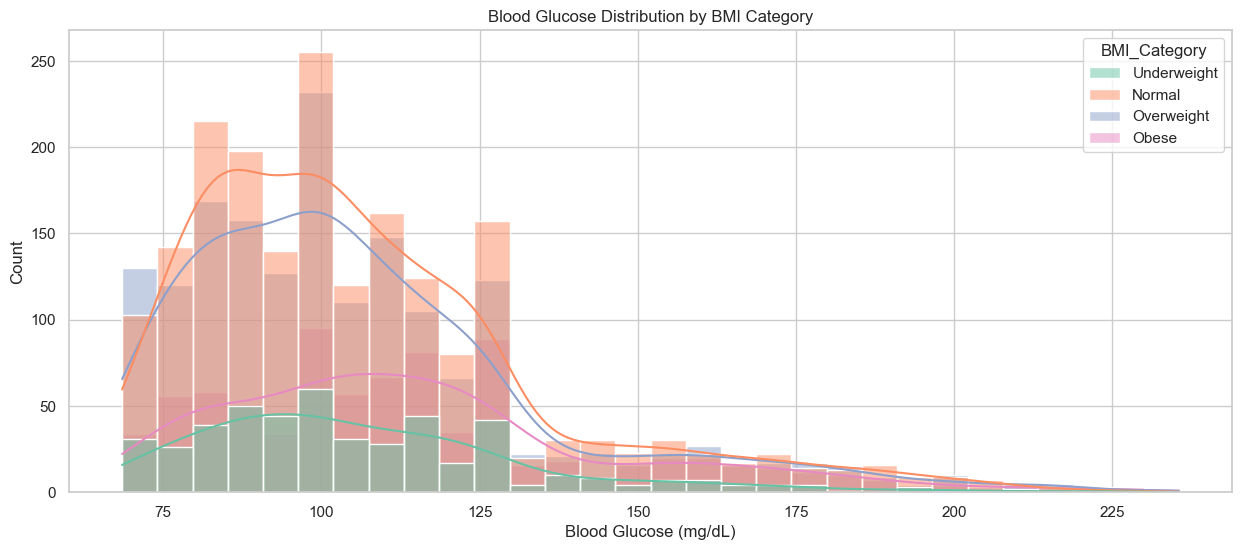

In [225]:
df['BMI_Category'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 40], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
plt.figure(figsize=(15, 6))
sns.histplot(data=df, x='blood_glucose', hue='BMI_Category', kde=True, palette='Set2', bins=30)
plt.title("Blood Glucose Distribution by BMI Category")
plt.xlabel("Blood Glucose (mg/dL)")
plt.ylabel("Count")
plt.show()

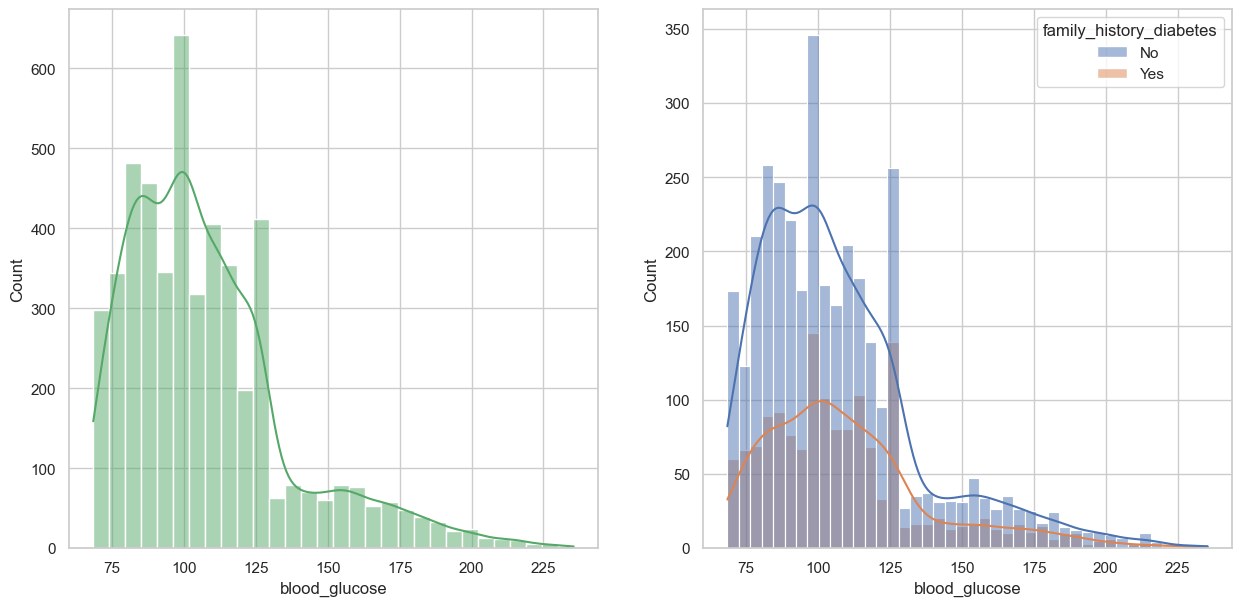

In [227]:
fig , ax = plt.subplots(1 ,2 , figsize = (15, 7))
plt.subplot(121)
sns.histplot(data = df , x ='blood_glucose' , bins =30 , kde = True , color = 'g')
plt.subplot(122)
sns.histplot(data = df , x='blood_glucose' , kde= True, hue= 'family_history_diabetes')
plt.show()

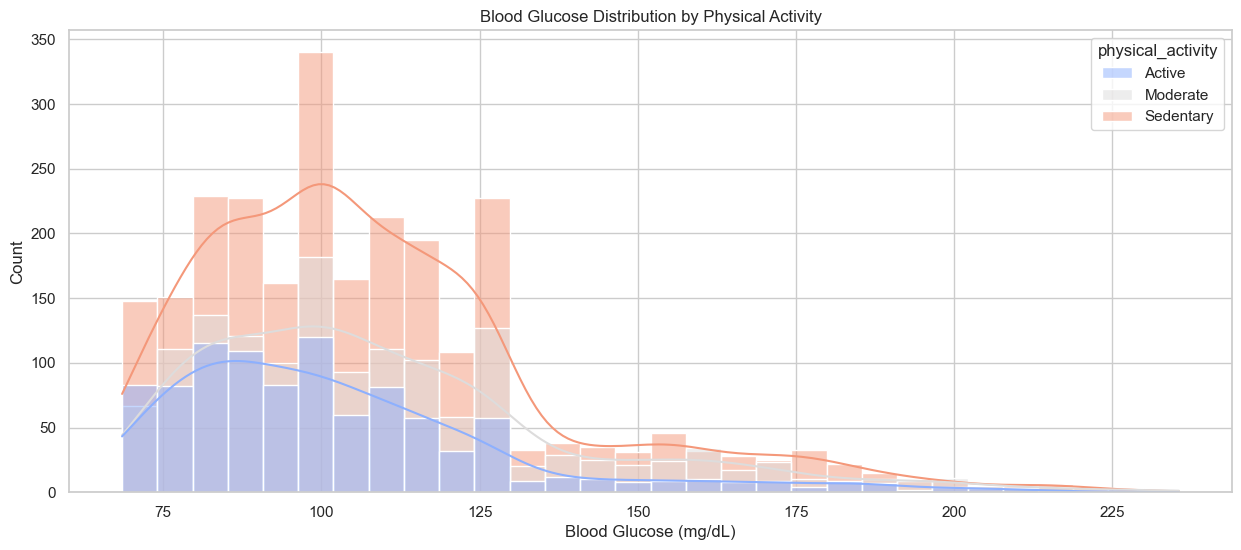

In [229]:
plt.figure(figsize=(15, 6))
sns.histplot(data=df, x='blood_glucose', hue='physical_activity', kde=True, palette='coolwarm', bins=30)
plt.title("Blood Glucose Distribution by Physical Activity")
plt.xlabel("Blood Glucose (mg/dL)")
plt.ylabel("Count")
plt.show()


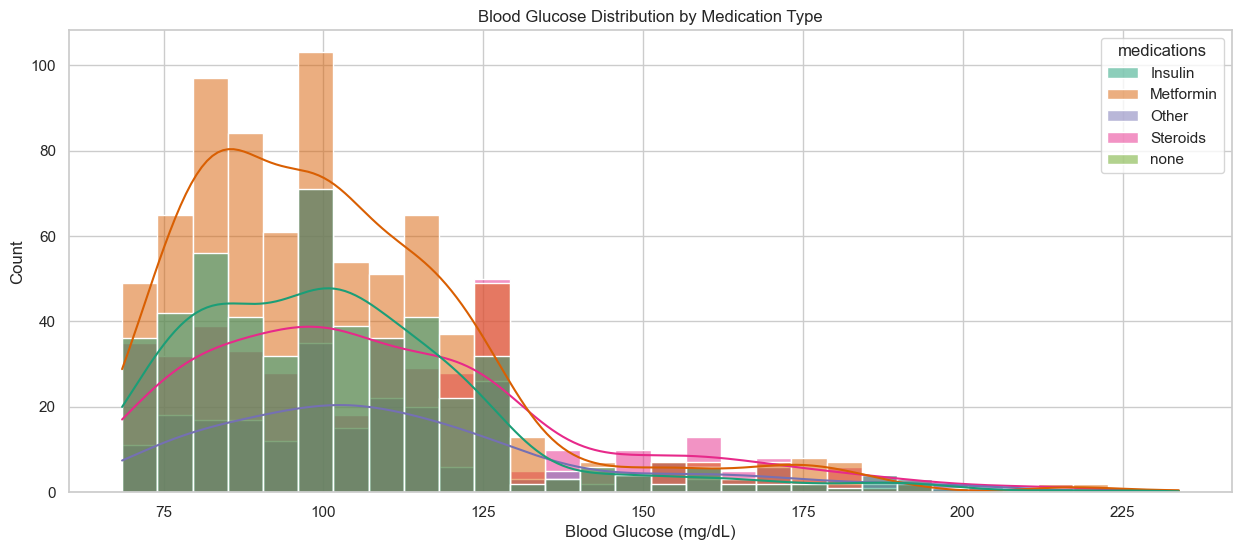

In [231]:
plt.figure(figsize=(15, 6))
sns.histplot(data=df[df['medications'] != 'none'], x='blood_glucose', hue='medications', kde=True, palette='Dark2', bins=30)
plt.title("Blood Glucose Distribution by Medication Type")
plt.xlabel("Blood Glucose (mg/dL)")
plt.ylabel("Count")
plt.show()


In [233]:
df[['bmi','BMI_Category']]

,bmi,BMI_Category
0,18.6,Normal
1,18.4,Underweight
2,18.0,Underweight
3,29.1,Overweight
4,29.1,Overweight
...,...,...
4995,26.0,Overweight
4996,21.6,Normal
4997,26.5,Overweight
4998,30.4,Obese


In [235]:
df.columns = df.columns.str.lower()

In [237]:
df.columns

Index(['age', 'sex', 'ethnicity', 'bmi', 'socioeconomic_status',
       'physical_activity', 'alcohol_consumption', 'smoking_status',
       'sleep_duration', 'sleep_quality', 'stress_levels',
       'family_history_diabetes', 'prediabetes', 'gestational_diabetes',
       'hypertension', 'pcos', 'cardiovascular_disease', 'kidney_problems',
       'medications', 'blood_pressure_systolic', 'blood_pressure_diastolic',
       'heart_rate', 'skin_temperature', 'blood_glucose', 'sensor_current_ua',
       'bmi_category'],
      dtype='object')

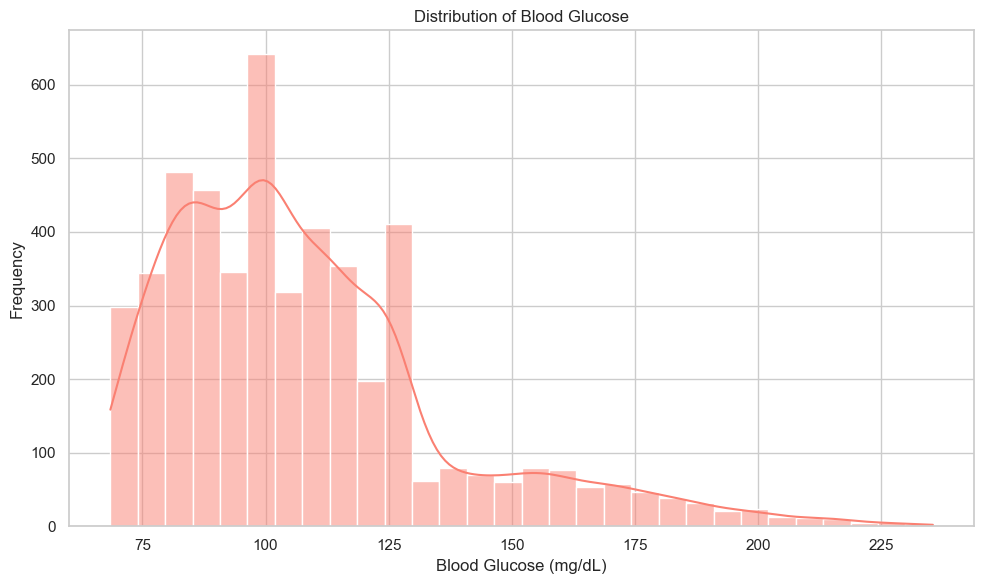

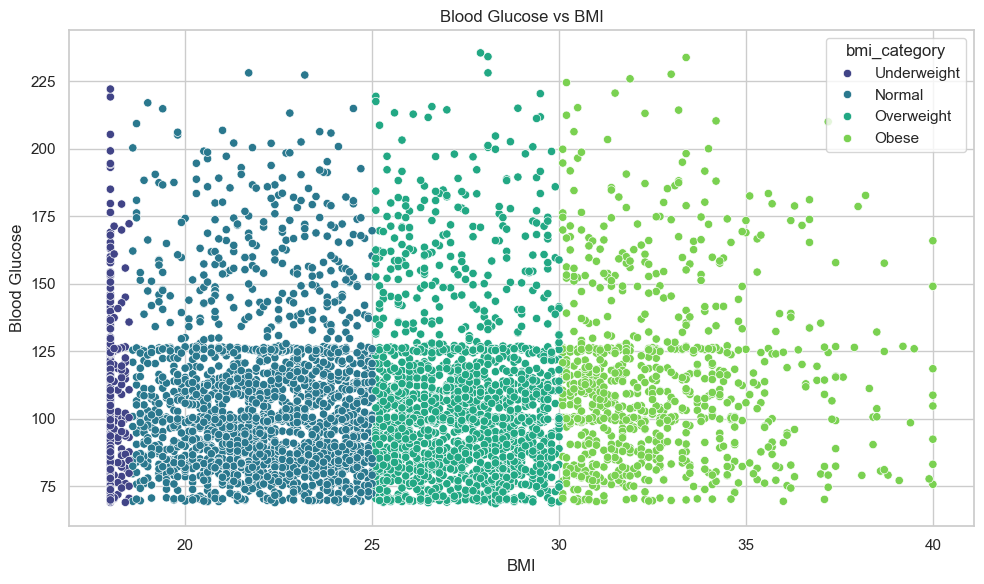

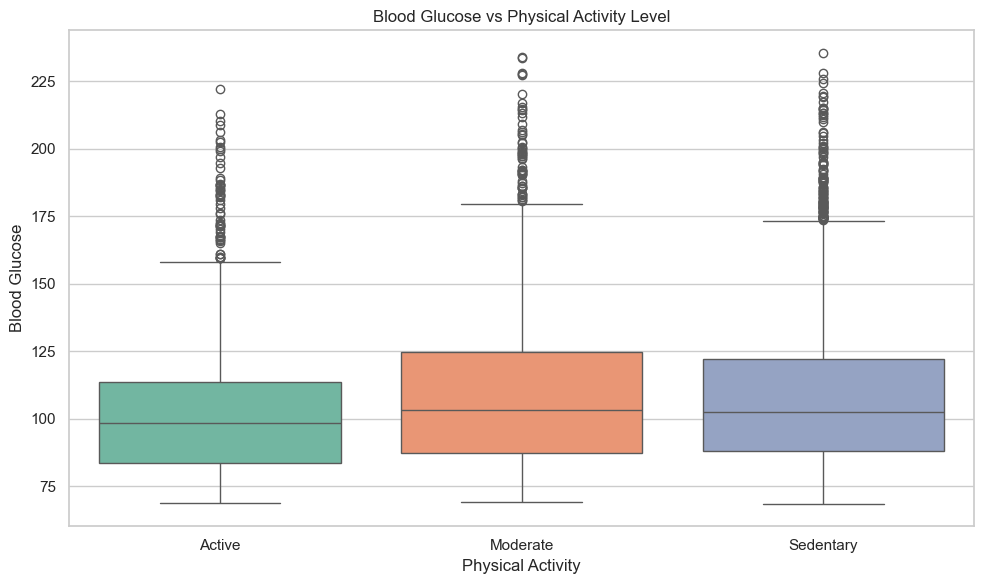

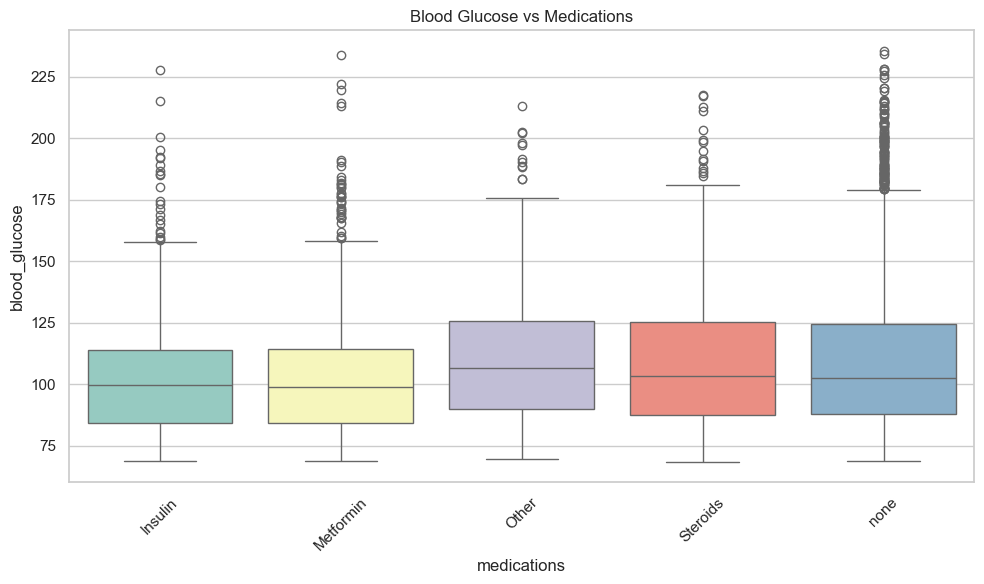

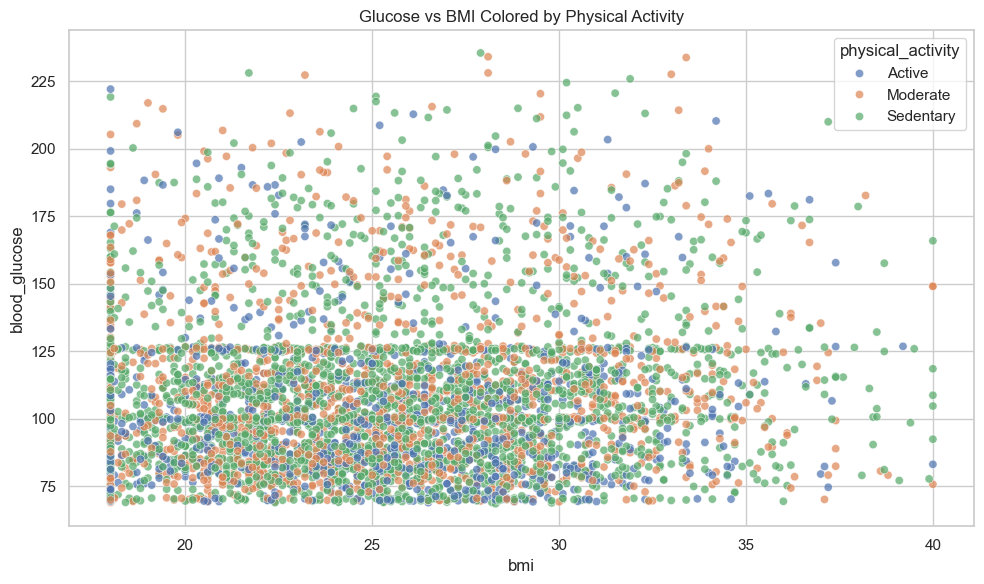

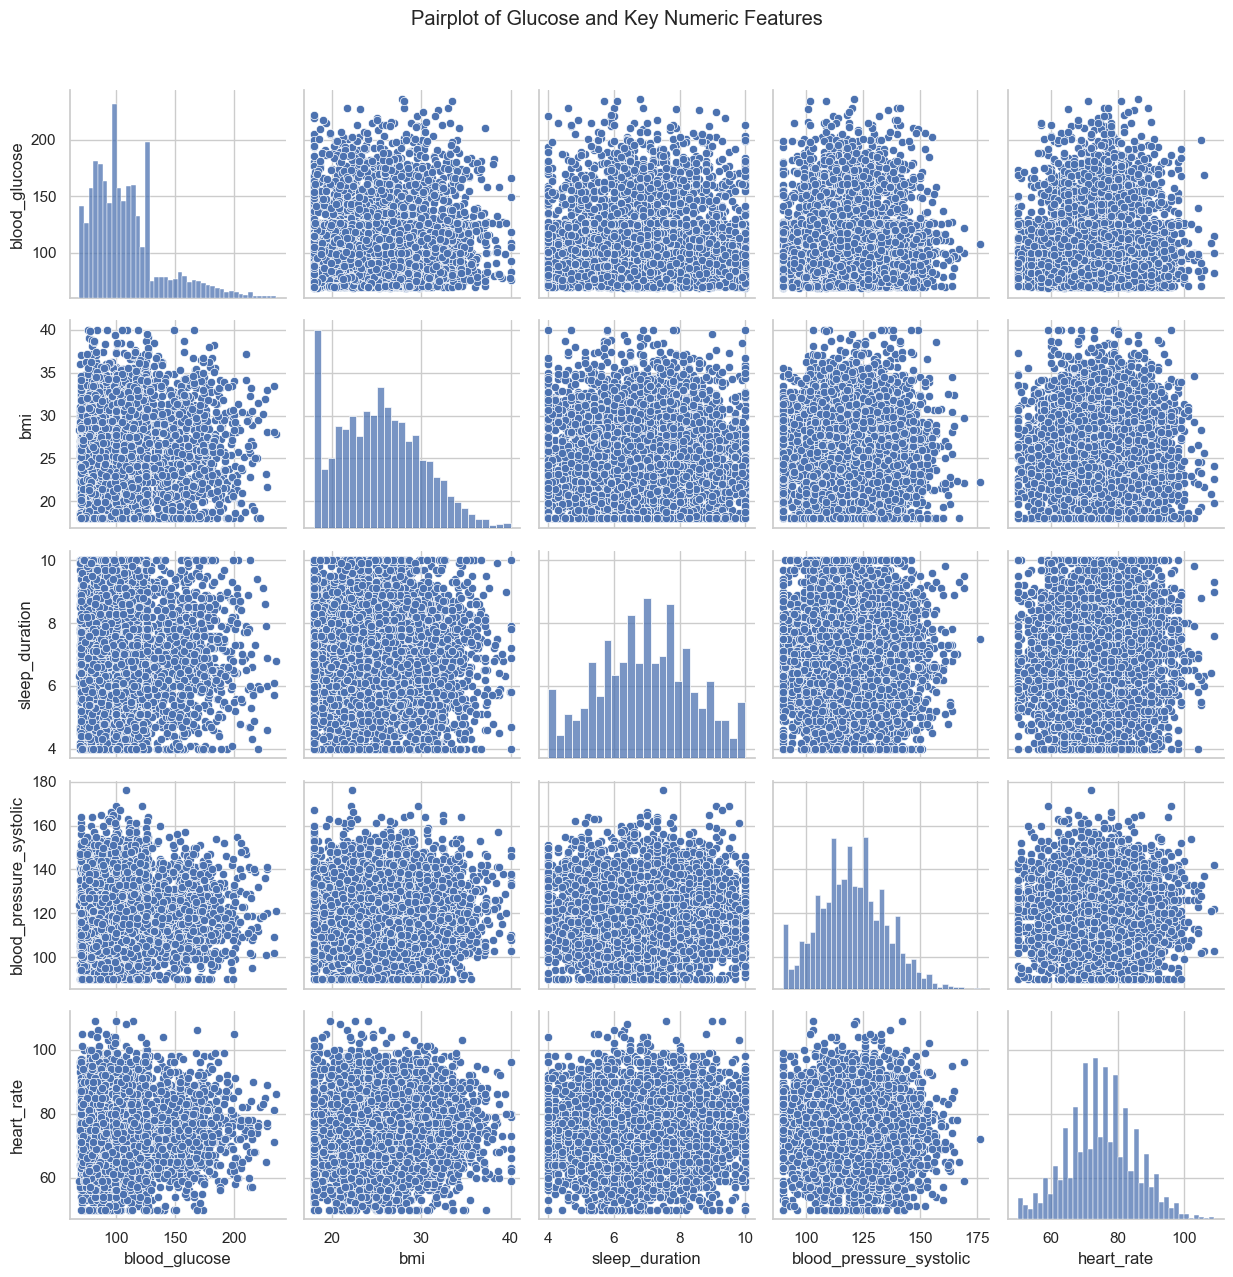

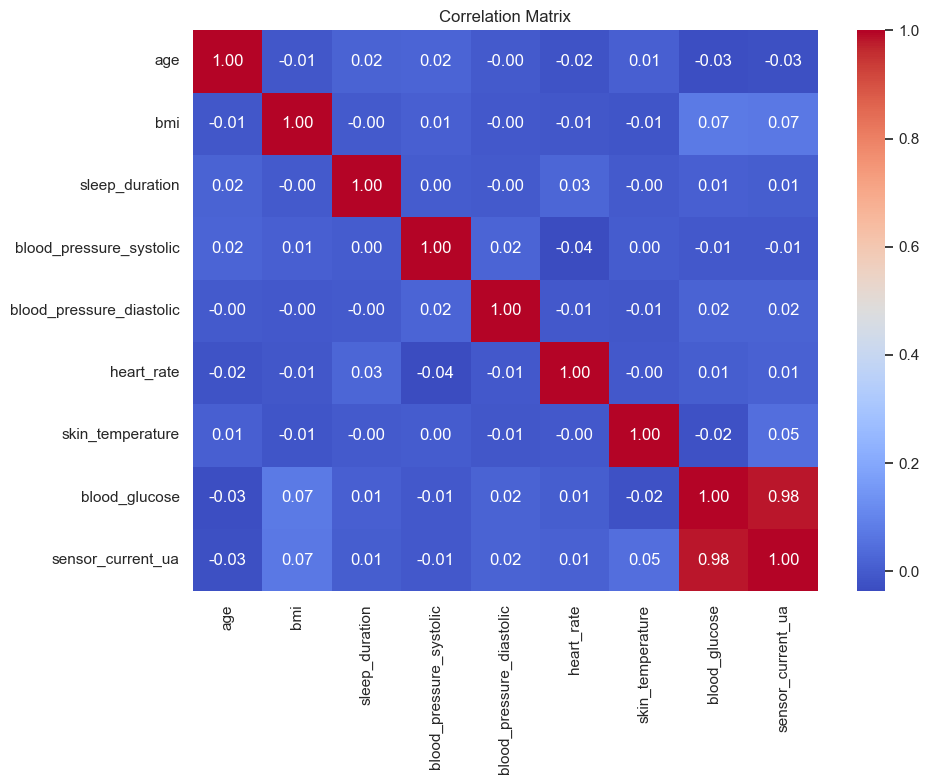

In [239]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Set visual style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ---------------- UNIVARIATE ANALYSIS ----------------
# Distribution of blood glucose
sns.histplot(df['blood_glucose'], kde=True, bins=30, color='salmon')
plt.title('Distribution of Blood Glucose')
plt.xlabel('Blood Glucose (mg/dL)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# ---------------- BIVARIATE ANALYSIS ----------------
# Glucose vs BMI (scatter)
sns.scatterplot(x='bmi', y='blood_glucose', hue='bmi_category', data=df, palette='viridis')
plt.title('Blood Glucose vs BMI')
plt.xlabel('BMI')
plt.ylabel('Blood Glucose')
plt.tight_layout()
plt.show()

# Boxplot of glucose by activity
sns.boxplot(x='physical_activity', y='blood_glucose', data=df, palette='Set2')
plt.title('Blood Glucose vs Physical Activity Level')
plt.xlabel('Physical Activity')
plt.ylabel('Blood Glucose')
plt.tight_layout()
plt.show()

# Boxplot of glucose by medication
sns.boxplot(x='medications', y='blood_glucose', data=df, palette='Set3')
plt.title('Blood Glucose vs Medications')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------- MULTIVARIATE ANALYSIS ----------------
# Glucose vs BMI vs Activity (using hue for activity)
sns.scatterplot(data=df, x='bmi', y='blood_glucose', hue='physical_activity', alpha=0.7)
plt.title('Glucose vs BMI Colored by Physical Activity')
plt.tight_layout()
plt.show()

# Pairplot with key numerical features
key_features = ['blood_glucose', 'bmi', 'sleep_duration', 'blood_pressure_systolic', 'heart_rate']
sns.pairplot(df[key_features])
plt.suptitle('Pairplot of Glucose and Key Numeric Features', y=1.02)
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


In [174]:
df.columns


Index(['Age', 'Sex', 'Ethnicity', 'BMI', 'Socioeconomic_Status',
       'Physical_Activity', 'Alcohol_Consumption', 'Smoking_Status',
       'Sleep_Duration', 'Sleep_Quality', 'Stress_Levels',
       'Family_History_Diabetes', 'Prediabetes', 'Gestational_Diabetes',
       'Hypertension', 'PCOS', 'Cardiovascular_Disease', 'Kidney_Problems',
       'Medications', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic',
       'Heart_Rate', 'Skin_Temperature', 'Blood_Glucose', 'Sensor_Current_uA',
       'Sensor_Voltage_mV'],
      dtype='object')